# Electro-Thermal Coupling Model

This notebook contains the final coupled electrical-thermal workflow for the IRFZ44N buck-converter MOSFET.

The coupled calculation links:

`Tj → Rds(on) → MOSFET loss → ANSYS thermal response → updated Tj`

and repeats until the junction-temperature change falls below **0.1°C**.

The coupling is applied only to the electrically derived **5 A, 10 A and 20 A** operating points. The imposed **10 W and 15 W** thermal-stress cases remain outside the electrical feedback loop.


In [ ]:
import numpy as np
import pandas as pd

## 1. Electrical Model Inputs

The electrical model uses the fixed buck-converter operating parameters and the IRFZ44N datasheet-based temperature dependence of Rds(on).

The electrical calculation follows:

**Tj → Rds(on) → conduction loss → switching loss → total MOSFET loss**

In [ ]:
# Fixed converter parameters

Vin = 24.0
fs = 50e3
D = 0.5

tr = 60e-9
tf = 45e-9

# Datasheet Rds(on) reference at 25°C
Rds_25 = 0.0175

# Temperature-dependent normalised Rds(on) data
temperature_points = np.array([25, 50, 75, 100, 125, 150, 175])

rds_factors = np.array([
    1.00,
    1.15,
    1.35,
    1.58,
    1.82,
    2.10,
    2.39
])

## 2. Temperature-Dependent Rds(on) Model

The IRFZ44N on-resistance increases with junction temperature.

The normalised datasheet values are interpolated so that Rds(on) can be estimated at temperatures between the available datasheet points.

In [ ]:
def get_rds_on(Tj):
    factor = np.interp(
        Tj,
        temperature_points,
        rds_factors
    )

    return Rds_25 * factor

## 3. MOSFET Electrical-Loss Solver

The electrical solver calculates:

- temperature-dependent Rds(on)
- conduction loss
- switching loss
- total MOSFET power loss

for a specified load current and junction temperature.

In [ ]:
def calculate_mosfet_loss(current, Tj):

    rds_on = get_rds_on(Tj)

    conduction_loss = (
        current**2
        * rds_on
        * D
    )

    switching_loss = (
        0.5
        * Vin
        * current
        * (tr + tf)
        * fs
    )

    total_loss = (
        conduction_loss
        + switching_loss
    )

    return {
        "Tj (°C)": Tj,
        "Current (A)": current,
        "Rds(on) (ohm)": rds_on,
        "Conduction loss (W)": conduction_loss,
        "Switching loss (W)": switching_loss,
        "Total loss (W)": total_loss
    }

### Solver Check

The loss solver is checked at known temperatures before the full coupling loop is used. At **10 A and 25°C**, the conservative expected total MOSFET loss is approximately **1.505 W**.


In [ ]:
result = calculate_mosfet_loss(
    current=10,
    Tj=25
)

print(f"Junction temperature: {result['Tj (°C)']:.1f} °C")
print(f"Current: {result['Current (A)']:.1f} A")
print(f"Rds(on): {result['Rds(on) (ohm)']:.5f} ohm")
print(f"Conduction loss: {result['Conduction loss (W)']:.3f} W")
print(f"Switching loss: {result['Switching loss (W)']:.3f} W")
print(f"Total MOSFET loss: {result['Total loss (W)']:.3f} W")

Junction temperature: 25.0 °C
Current: 10.0 A
Rds(on): 0.01750 ohm
Conduction loss: 0.875 W
Switching loss: 0.630 W
Total MOSFET loss: 1.505 W


In [ ]:
result = calculate_mosfet_loss(
    current=10,
    Tj=100
)

print(f"Junction temperature: {result['Tj (°C)']:.1f} °C")
print(f"Current: {result['Current (A)']:.1f} A")
print(f"Rds(on): {result['Rds(on) (ohm)']:.5f} ohm")
print(f"Conduction loss: {result['Conduction loss (W)']:.3f} W")
print(f"Switching loss: {result['Switching loss (W)']:.3f} W")
print(f"Total MOSFET loss: {result['Total loss (W)']:.3f} W")

Junction temperature: 100.0 °C
Current: 10.0 A
Rds(on): 0.02765 ohm
Conduction loss: 1.383 W
Switching loss: 0.630 W
Total MOSFET loss: 2.013 W


## 5. Validated ANSYS Thermal Response

The validated ANSYS model provides the relationship between MOSFET heat input and junction temperature for the reference aluminium heat-sink configuration.

The selected FEA heat-load points are used to construct a thermal-response curve for the electro-thermal coupling model.

In [ ]:
thermal_power_al = np.array([
    0.534,
    1.505,
    4.760,
    10.0,
    15.0
])

thermal_temperature_al = np.array([
    27.798,
    32.885,
    49.938,
    77.390,
    103.595
])

# Copper ANSYS response
thermal_power_cu = np.array([
    0.534,
    1.505,
    4.760,
    10.0,
    15.0
])

thermal_temperature_cu = np.array([
    27.728,
    32.688,
    49.315,
    76.082,
    101.624
])

In [ ]:
def get_thermal_temperature_aluminium(power_loss):
    return np.interp(
        power_loss,
        thermal_power_al,
        thermal_temperature_al
    )

def get_thermal_temperature_copper(power_loss):
    return np.interp(
        power_loss,
        thermal_power_cu,
        thermal_temperature_cu
    )

## 6. Electro-Thermal Coupling Method

The coupled calculation follows:

**Assumed Tj → Rds(on) → MOSFET loss → interpolated ANSYS temperature → updated Tj**

The process is repeated until the change in junction temperature between successive iterations is less than **0.1°C**.

Because MOSFET loss is calculated directly from junction temperature, convergence of Tj also causes the electrical loss to converge.

In [ ]:
def run_coupled_case(
    current,
    thermal_function,
    initial_Tj=25.0,
    tolerance=0.1,
    max_iterations=20
):

    Tj = initial_Tj
    iterations = []

    for iteration in range(1, max_iterations + 1):

        electrical = calculate_mosfet_loss(
            current=current,
            Tj=Tj
        )

        power_loss = electrical["Total loss (W)"]

        new_Tj = thermal_function(power_loss)

        temperature_change = abs(new_Tj - Tj)

        iterations.append({
            "Iteration": iteration,
            "Tj input (°C)": Tj,
            "Rds(on) (ohm)": electrical["Rds(on) (ohm)"],
            "Conduction loss (W)": electrical["Conduction loss (W)"],
            "Switching loss (W)": electrical["Switching loss (W)"],
            "Total loss (W)": power_loss,
            "New Tj (°C)": new_Tj,
            "Temperature change (°C)": temperature_change
        })

        if temperature_change < tolerance:
            break

        Tj = new_Tj

    return pd.DataFrame(iterations)

## 7. Coupled Electrical Operating Results

The aluminium and copper cooling designs are solved at **5 A, 10 A and 20 A** using the same convergence criterion.


### 7.1 Aluminium Heat Sink


In [ ]:
results_al_5A = run_coupled_case(
    5,
    get_thermal_temperature_aluminium
)

results_al_10A = run_coupled_case(
    10,
    get_thermal_temperature_aluminium
)

results_al_20A = run_coupled_case(
    20,
    get_thermal_temperature_aluminium
)

In [ ]:
results_al_5A.round(4)

,Iteration,Tj input (°C),Rds(on) (ohm),Conduction loss (W),Switching loss (W),Total loss (W),New Tj (°C),Temperature change (°C)
0,1,25.000,0.0175,0.2188,0.315,0.5338,27.7980,2.7980
1,2,27.798,0.0178,0.2224,0.315,0.5374,27.8159,0.0179


In [ ]:
results_al_10A.round(4)


,Iteration,Tj input (°C),Rds(on) (ohm),Conduction loss (W),Switching loss (W),Total loss (W),New Tj (°C),Temperature change (°C)
0,1,25.0000,0.0175,0.8750,0.63,1.5050,32.8850,7.8850
1,2,32.8850,0.0183,0.9164,0.63,1.5464,33.1019,0.2169
2,3,33.1019,0.0184,0.9175,0.63,1.5475,33.1078,0.0060


In [ ]:
results_al_20A.round(4)

,Iteration,Tj input (°C),Rds(on) (ohm),Conduction loss (W),Switching loss (W),Total loss (W),New Tj (°C),Temperature change (°C)
0,1,25.0000,0.0175,3.5000,1.26,4.7600,49.9380,24.9380
1,2,49.9380,0.0201,4.0237,1.26,5.2837,52.6816,2.7436
2,3,52.6816,0.0205,4.1001,1.26,5.3601,53.0818,0.4002
3,4,53.0818,0.0206,4.1113,1.26,5.3713,53.1405,0.0587


### 7.2 Copper Heat Sink


In [ ]:
results_cu_5A = run_coupled_case(
    5,
    get_thermal_temperature_copper
)

results_cu_10A = run_coupled_case(
    10,
    get_thermal_temperature_copper
)

results_cu_20A = run_coupled_case(
    20,
    get_thermal_temperature_copper
)

In [ ]:
results_cu_5A.round(4)

,Iteration,Tj input (°C),Rds(on) (ohm),Conduction loss (W),Switching loss (W),Total loss (W),New Tj (°C),Temperature change (°C)
0,1,25.000,0.0175,0.2188,0.315,0.5338,27.728,2.728
1,2,27.728,0.0178,0.2223,0.315,0.5373,27.745,0.017


In [ ]:
results_cu_10A.round(4)

,Iteration,Tj input (°C),Rds(on) (ohm),Conduction loss (W),Switching loss (W),Total loss (W),New Tj (°C),Temperature change (°C)
0,1,25.0000,0.0175,0.8750,0.63,1.5050,32.6880,7.6880
1,2,32.6880,0.0183,0.9154,0.63,1.5454,32.8942,0.2062
2,3,32.8942,0.0183,0.9164,0.63,1.5464,32.8997,0.0055


In [ ]:
results_cu_20A.round(4)

,Iteration,Tj input (°C),Rds(on) (ohm),Conduction loss (W),Switching loss (W),Total loss (W),New Tj (°C),Temperature change (°C)
0,1,25.0000,0.0175,3.5000,1.26,4.7600,49.3150,24.3150
1,2,49.3150,0.0201,4.0106,1.26,5.2706,51.9233,2.6083
2,3,51.9233,0.0204,4.0789,1.26,5.3389,52.2719,0.3486
3,4,52.2719,0.0204,4.0886,1.26,5.3486,52.3218,0.0499


## 8. 10 A No-Heat-Sink Electro-Thermal Coupling

The no-heat-sink case is coupled separately from the cooled ANSYS-based cases.

The cooled cases use the validated ANSYS heat-load-to-temperature response, while the no-heat-sink case uses the IRFZ44N junction-to-ambient thermal resistance.

The no-heat-sink temperature is therefore updated using:

**Tj,new = Ta + Ploss(Tj) × RθJA**

where:

- **Ta = 25°C**
- **RθJA = 62°C/W**
- **Current = 10 A**
- **Rds(on) is updated with junction temperature**
- **Switching loss is recalculated using the existing electrical model**

The iteration is stopped when the junction-temperature change is below **0.1°C**, or when the predicted junction temperature reaches the **175°C absolute limit**.

In [ ]:
# 10 A no-heat-sink electro-thermal coupling

T_ambient = 25.0
R_theta_JA = 62.0
Tj_limit = 175.0

def run_no_heatsink_coupled_case(
    current=10,
    initial_Tj=25.0,
    tolerance=0.1,
    max_iterations=20
):
    Tj = initial_Tj
    iterations = []

    for iteration in range(1, max_iterations + 1):

        electrical = calculate_mosfet_loss(
            current=current,
            Tj=Tj
        )

        power_loss = electrical["Total loss (W)"]

        new_Tj = (
            T_ambient
            + power_loss * R_theta_JA
        )

        temperature_change = abs(new_Tj - Tj)

        iterations.append({
            "Iteration": iteration,
            "Tj input (°C)": Tj,
            "Rds(on) (ohm)": electrical["Rds(on) (ohm)"],
            "Conduction loss (W)": electrical["Conduction loss (W)"],
            "Switching loss (W)": electrical["Switching loss (W)"],
            "Total loss (W)": power_loss,
            "New Tj (°C)": new_Tj,
            "Temperature change (°C)": temperature_change
        })

        # Stop if device limit is reached
        if new_Tj >= Tj_limit:
            print(
                f"Stopped: predicted junction temperature "
                f"reached/exceeded {Tj_limit:.0f}°C."
            )
            break

        # Stop if converged
        if temperature_change < tolerance:
            print("No-heat-sink case converged.")
            break

        Tj = new_Tj

    return pd.DataFrame(iterations)

In [ ]:
results_no_heatsink_10A = run_no_heatsink_coupled_case(
    current=10
)

results_no_heatsink_10A.round(4)

Stopped: predicted junction temperature reached/exceeded 175°C.


,Iteration,Tj input (°C),Rds(on) (ohm),Conduction loss (W),Switching loss (W),Total loss (W),New Tj (°C),Temperature change (°C)
0,1,25.0000,0.0175,0.8750,0.63,1.5050,118.3100,93.3100
1,2,118.3100,0.0307,1.5363,0.63,2.1663,159.3108,41.0008
2,3,159.3108,0.0386,1.9320,0.63,2.5620,183.8443,24.5335


### No-Heat-Sink Result

The 10 A no-heat-sink case does not reach a safe converged operating point before exceeding the **175°C absolute junction-temperature limit**.

The predicted junction temperature rises from **118.31°C** after the first electrical-thermal pass to **159.31°C** after feedback is included, and then to **183.84°C** on the following iteration.

The calculation is therefore stopped when the device temperature limit is exceeded.

This demonstrates the positive electro-thermal feedback mechanism:

**higher Tj → higher Rds(on) → higher conduction loss → greater heat generation → higher Tj**

## 9. Overall Coupled Comparison

In [ ]:
# Helper function to extract the final row from a coupled result

def final_result(result_df, material, current, status="Converged"):

    final = result_df.iloc[-1]

    return {
        "Cooling case": material,
        "Current (A)": current,
        "Final Tj (°C)": final["New Tj (°C)"],
        "Final Rds(on) (ohm)": final["Rds(on) (ohm)"],
        "Final conduction loss (W)": final["Conduction loss (W)"],
        "Final switching loss (W)": final["Switching loss (W)"],
        "Final total loss (W)": final["Total loss (W)"],
        "Iterations": int(final["Iteration"]),
        "Status": status
    }


comparison_rows = [

    # Aluminium
    final_result(results_al_5A, "Aluminium heat sink", 5),
    final_result(results_al_10A, "Aluminium heat sink", 10),
    final_result(results_al_20A, "Aluminium heat sink", 20),

    # Copper
    final_result(results_cu_5A, "Copper heat sink", 5),
    final_result(results_cu_10A, "Copper heat sink", 10),
    final_result(results_cu_20A, "Copper heat sink", 20),

    # No heat sink
    final_result(
        results_no_heatsink_10A,
        "No heat sink",
        10,
        status="Exceeded 175°C limit"
    )
]

overall_comparison = pd.DataFrame(comparison_rows)
Vout = 12.0

overall_comparison["Output power (W)"] = (
    Vout * overall_comparison["Current (A)"]
)

overall_comparison["MOSFET efficiency (%)"] = (
    overall_comparison["Output power (W)"]
    /
    (
        overall_comparison["Output power (W)"]
        + overall_comparison["Final total loss (W)"]
    )
    * 100
)

Tj_target = 125.0
Tj_limit = 175.0

overall_comparison["Margin to 125°C target (°C)"] = (
    Tj_target - overall_comparison["Final Tj (°C)"]
)

overall_comparison["Margin to 175°C limit (°C)"] = (
    Tj_limit - overall_comparison["Final Tj (°C)"]
)

overall_comparison.round(4)

,Cooling case,Current (A),Final Tj (°C),Final Rds(on) (ohm),Final conduction loss (W),Final switching loss (W),Final total loss (W),Iterations,Status,Output power (W),MOSFET efficiency (%),Margin to 125°C target (°C),Margin to 175°C limit (°C)
0,Aluminium heat sink,5,27.8159,0.0178,0.2224,0.315,0.5374,2,Converged,60.0,99.1122,97.1841,147.1841
1,Aluminium heat sink,10,33.1078,0.0184,0.9175,0.630,1.5475,3,Converged,120.0,98.7268,91.8922,141.8922
2,Aluminium heat sink,20,53.1405,0.0206,4.1113,1.260,5.3713,4,Converged,240.0,97.8110,71.8595,121.8595
3,Copper heat sink,5,27.7450,0.0178,0.2223,0.315,0.5373,2,Converged,60.0,99.1124,97.2550,147.2550
4,Copper heat sink,10,32.8997,0.0183,0.9164,0.630,1.5464,3,Converged,120.0,98.7277,92.1003,142.1003
5,Copper heat sink,20,52.3218,0.0204,4.0886,1.260,5.3486,4,Converged,240.0,97.8200,72.6782,122.6782
6,No heat sink,10,183.8443,0.0386,1.9320,0.630,2.5620,3,Exceeded 175°C limit,120.0,97.9096,-58.8443,-8.8443


### Overall Comparison Interpretation

The coupled results allow the effect of cooling configuration on both MOSFET temperature and electrical loss to be compared directly.

The aluminium and copper heat-sink cases are evaluated at **5 A, 10 A and 20 A** and are iterated until junction temperature converges.

The no-heat-sink case is included separately at the **10 A baseline operating point**. This case does not reach a safe converged operating condition before the predicted junction temperature exceeds the **175°C absolute device limit**.

The comparison therefore demonstrates two effects:

- Improved cooling reduces junction temperature.
- Lower junction temperature suppresses the increase in Rds(on), reducing the electro-thermal increase in conduction loss.

The no-heat-sink result provides a clear reference showing why dedicated MOSFET thermal management is required at the baseline operating condition.

## Junction Temperature and Thermal Margin

Thermal margin is evaluated relative to the selected **125°C project junction-temperature target** and the **175°C absolute IRFZ44N junction-temperature limit**.

A positive thermal margin indicates that the operating point remains below the corresponding temperature threshold.

The aluminium and copper heat-sink cases remain comfortably below both temperature limits at **5 A, 10 A and 20 A**.

At 20 A, the aluminium heat sink reaches approximately **53.14°C**, giving a margin of approximately **71.86°C** to the 125°C project target. The copper heat sink reaches approximately **52.32°C**, giving a slightly larger margin of approximately **72.68°C**.

The difference between aluminium and copper remains small under the current baseline geometry and operating conditions.

The 10 A no-heat-sink case exceeds the **175°C absolute junction-temperature limit**, confirming that it is thermally unacceptable under the coupled model.

## 10. One-Pass vs Coupled Comparison

The one-pass calculation assumes an initial junction temperature of **25°C**, calculates the MOSFET loss once, and then obtains the corresponding thermal-model temperature without feeding that temperature back into the electrical model.

The coupled calculation repeatedly updates:

**Tj → Rds(on) → MOSFET loss → thermal-model temperature**

until the junction temperature converges.

Comparing the two methods quantifies the effect of temperature-dependent electro-thermal feedback.

In [ ]:
def run_one_pass_case(current, thermal_function, initial_Tj=25.0):

    electrical = calculate_mosfet_loss(
        current=current,
        Tj=initial_Tj
    )

    power_loss = electrical["Total loss (W)"]

    new_Tj = thermal_function(power_loss)

    return {
        "Current (A)": current,
        "One-pass Tj (°C)": new_Tj,
        "One-pass Rds(on) (ohm)": electrical["Rds(on) (ohm)"],
        "One-pass total loss (W)": power_loss
    }

In [ ]:
one_pass_al_5A = run_one_pass_case(
    5,
    get_thermal_temperature_aluminium
)

one_pass_al_10A = run_one_pass_case(
    10,
    get_thermal_temperature_aluminium
)

one_pass_al_20A = run_one_pass_case(
    20,
    get_thermal_temperature_aluminium
)

In [ ]:
one_pass_cu_5A = run_one_pass_case(
    5,
    get_thermal_temperature_copper
)

one_pass_cu_10A = run_one_pass_case(
    10,
    get_thermal_temperature_copper
)

one_pass_cu_20A = run_one_pass_case(
    20,
    get_thermal_temperature_copper
)

In [ ]:
def get_converged_values(result_df):

    final = result_df.iloc[-1]

    return {
        "Coupled Tj (°C)": final["New Tj (°C)"],
        "Coupled total loss (W)": final["Total loss (W)"]
    }

In [ ]:
comparison_rows = []

cases = [
    ("Aluminium", 5, one_pass_al_5A, results_al_5A),
    ("Aluminium", 10, one_pass_al_10A, results_al_10A),
    ("Aluminium", 20, one_pass_al_20A, results_al_20A),

    ("Copper", 5, one_pass_cu_5A, results_cu_5A),
    ("Copper", 10, one_pass_cu_10A, results_cu_10A),
    ("Copper", 20, one_pass_cu_20A, results_cu_20A),
]

for material, current, one_pass, coupled_df in cases:

    coupled = get_converged_values(coupled_df)

    one_pass_loss = one_pass["One-pass total loss (W)"]
    coupled_loss = coupled["Coupled total loss (W)"]

    loss_increase = coupled_loss - one_pass_loss

    loss_increase_percent = (
        loss_increase / one_pass_loss * 100
    )

    comparison_rows.append({
        "Material": material,
        "Current (A)": current,

        "One-pass Tj (°C)": one_pass["One-pass Tj (°C)"],
        "Coupled Tj (°C)": coupled["Coupled Tj (°C)"],

        "One-pass loss (W)": one_pass_loss,
        "Coupled loss (W)": coupled_loss,

        "Temperature increase from feedback (°C)":
            coupled["Coupled Tj (°C)"]
            - one_pass["One-pass Tj (°C)"],

        "Loss increase from feedback (W)":
            loss_increase,

        "Loss increase from feedback (%)":
            loss_increase_percent
    })

one_pass_vs_coupled = pd.DataFrame(comparison_rows)

one_pass_vs_coupled.round(4)

,Material,Current (A),One-pass Tj (°C),Coupled Tj (°C),One-pass loss (W),Coupled loss (W),Temperature increase from feedback (°C),Loss increase from feedback (W),Loss increase from feedback (%)
0,Aluminium,5,27.798,27.8159,0.5338,0.5374,0.0179,0.0037,0.6880
1,Aluminium,10,32.885,33.1078,1.5050,1.5475,0.2228,0.0425,2.8262
2,Aluminium,20,49.938,53.1405,4.7600,5.3713,3.2025,0.6113,12.8422
3,Copper,5,27.728,27.7450,0.5338,0.5373,0.0170,0.0036,0.6708
4,Copper,10,32.688,32.8997,1.5050,1.5464,0.2117,0.0414,2.7538
5,Copper,20,49.315,52.3218,4.7600,5.3486,3.0068,0.5886,12.3658


### Feedback Strength Interpretation

The difference between the one-pass and coupled results increases as load current rises.

At low current, conduction loss is relatively small, so the increase in Rds(on) caused by junction-temperature rise produces only a minor increase in total MOSFET loss.

At higher current, conduction loss becomes much larger because it scales approximately with current squared. Therefore, the same temperature-dependent increase in Rds(on) produces a larger additional power loss.

The 20 A operating point shows the largest difference between the one-pass and coupled results, demonstrating that electro-thermal feedback becomes materially more significant at higher current.

This confirms that temperature-dependent electrical behaviour becomes increasingly important as converter loading increases.

## 11. Coupling Criteria and Case Definition

The electro-thermal coupling was applied to the electrically derived **5 A, 10 A and 20 A** operating cases. The **10 W and 15 W thermal-stress cases are kept outside the electrical coupling loop because they are imposed heat loads rather than converter-derived MOSFET losses.

The following criteria are used throughout the coupling study:

- Junction-temperature convergence tolerance: **0.1°C**
- Maximum number of iterations: **20**
- Project junction-temperature target: **125°C**
- IRFZ44N absolute maximum junction temperature: **175°C**

A coupled electrical case is considered converged when the junction-temperature change between successive iterations falls below **0.1°C**.

If the predicted junction temperature reaches or exceeds **175°C**, the calculation is stopped and the configuration is classified as exceeding the device temperature limit.

## Thermal-Stress Cases

The 10 W and 15 W cases are imposed thermal-stress cases used to assess cooling-system performance under substantially higher heat dissipation.

They are kept separate from the 5 A, 10 A and 20 A electrically derived cases because they do not correspond to defined converter operating currents and are therefore not included in the electrical feedback loop.

In [ ]:
stress_results = pd.DataFrame({
    "Material": [
        "Aluminium",
        "Copper",
        "Aluminium",
        "Copper"
    ],
    "Heat load (W)": [
        10,
        10,
        15,
        15
    ],
    "Junction temperature (°C)": [
        77.390,  # aluminium 10 W,
        76.082,  # copper 10 W,
        103.595,  # aluminium 15 W,
        101.624   # copper 15 W
    ]
    
})

stress_results["Margin to 125°C target (°C)"] = (
    125 - stress_results["Junction temperature (°C)"]
)

stress_results["Margin to 175°C limit (°C)"] = (
    175 - stress_results["Junction temperature (°C)"]
)

stress_results.round(3)


,Material,Heat load (W),Junction temperature (°C),Margin to 125°C target (°C),Margin to 175°C limit (°C)
0,Aluminium,10,77.390,47.610,97.610
1,Copper,10,76.082,48.918,98.918
2,Aluminium,15,103.595,21.405,71.405
3,Copper,15,101.624,23.376,73.376


## Electrical and Thermal Comparison Plots

The following plots summarise the effect of operating current and cooling material on MOSFET electrical performance and thermal behaviour.

The electrically derived 5 A, 10 A and 20 A cases are used for the loss and efficiency comparisons.

The imposed 10 W and 15 W thermal-stress cases are kept separate and are used only to compare the thermal response of aluminium and copper heat sinks.

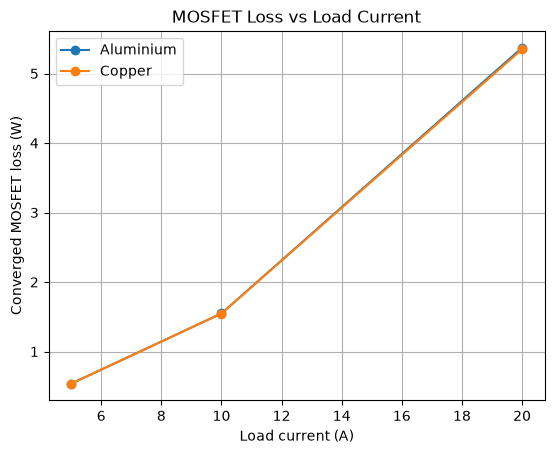

In [ ]:
import matplotlib.pyplot as plt

al_data = overall_comparison[
    overall_comparison["Cooling case"] == "Aluminium heat sink"
]

cu_data = overall_comparison[
    overall_comparison["Cooling case"] == "Copper heat sink"
]

plt.figure()

plt.plot(
    al_data["Current (A)"],
    al_data["Final total loss (W)"],
    marker="o",
    label="Aluminium"
)

plt.plot(
    cu_data["Current (A)"],
    cu_data["Final total loss (W)"],
    marker="o",
    label="Copper"
)

plt.xlabel("Load current (A)")
plt.ylabel("Converged MOSFET loss (W)")
plt.title("MOSFET Loss vs Load Current")
plt.legend()
plt.grid()

plt.show()

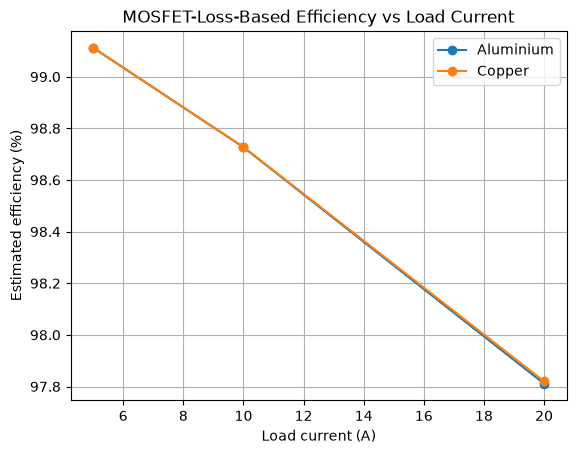

In [ ]:
plt.figure()

plt.plot(
    al_data["Current (A)"],
    al_data["MOSFET efficiency (%)"],
    marker="o",
    label="Aluminium"
)

plt.plot(
    cu_data["Current (A)"],
    cu_data["MOSFET efficiency (%)"],
    marker="o",
    label="Copper"
)

plt.xlabel("Load current (A)")
plt.ylabel("Estimated efficiency (%)")
plt.title("MOSFET-Loss-Based Efficiency vs Load Current")
plt.legend()
plt.grid()

plt.show()

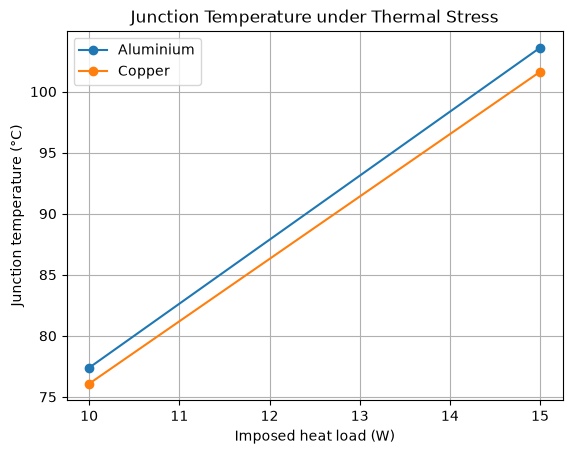

In [ ]:
plt.figure()

al_stress = stress_results[
    stress_results["Material"] == "Aluminium"
]

cu_stress = stress_results[
    stress_results["Material"] == "Copper"
]

plt.plot(
    al_stress["Heat load (W)"],
    al_stress["Junction temperature (°C)"],
    marker="o",
    label="Aluminium"
)

plt.plot(
    cu_stress["Heat load (W)"],
    cu_stress["Junction temperature (°C)"],
    marker="o",
    label="Copper"
)

plt.xlabel("Imposed heat load (W)")
plt.ylabel("Junction temperature (°C)")
plt.title("Junction Temperature under Thermal Stress")
plt.legend()
plt.grid()

plt.show()

### Plot Interpretation

The converged MOSFET loss increases strongly with load current because both conduction loss and switching loss increase as current rises. Temperature-dependent Rds(on) further increases conduction loss through electro-thermal feedback.

The estimated MOSFET-loss-based efficiency decreases slightly as current increases because MOSFET power dissipation becomes a larger electrical penalty at higher load.

The difference between aluminium and copper is small across the electrically derived 5 A, 10 A and 20 A cases. Copper produces slightly lower junction temperatures and therefore slightly lower Rds(on) and MOSFET loss, but the resulting electrical-efficiency improvement is very small.

The imposed thermal-stress cases show a clearer material difference. At 10 W, the aluminium junction temperature is approximately **77.39°C**, compared with **76.08°C** for copper, a difference of approximately **1.31°C**.

At 15 W, the aluminium junction temperature rises to approximately **103.60°C**, compared with **101.62°C** for copper, increasing the material difference to approximately **1.97°C**.

This shows that the thermal advantage of copper becomes more noticeable as heat dissipation increases, although the improvement remains relatively modest for the current heat-sink geometry. This result will later be considered alongside mass, cost and manufacturability when determining whether the additional thermal performance of copper justifies its practical penalties.

## 12. Final Coupling Summary

The final coupled model demonstrates that:

- the 5 A, 10 A and 20 A cooled cases converge safely,
- temperature-dependent Rds(on) produces increasingly important feedback as current rises,
- the 20 A case shows the largest increase from one-pass to coupled loss,
- aluminium and copper give similar electrical performance under the baseline geometry, and
- the 10 A no-heat-sink case exceeds the 175°C absolute junction-temperature limit before reaching a safe converged operating point.

The coupled outputs are the final electrical-thermal operating results used by the master results table and engineering assessment.
